### [과제- iris 사진보고 분류하기 ] <hr>

- 방향--> 
    * [1] 데이터 준비
         - 이미지 폴더 3개
         - 이미지 읽기
         - grayscale 변환
         - resize
         - flatten
         - label 붙이기
         - 하나의 CSV 저장
    
    * [2] 타겟 분리
        - CSV 불러와서 X, y 분리
        - train_test_split
    * [3] 학습
        - KNN/ SVC
        - knn-> GridSearchCV / RandomizedSearchCV
        - 결과 시각화

- **[0] 모듈 로딩**

In [2]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import importlib
import cv_utils
importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

- **[1] 데이터 준비**

In [3]:
# 데이터 폴더 불러오기

DATA_DIRS= [
    "../Day03/iris-setosa",
    "../Day03/iris-versicolour",
    "../Day03/iris-virginica"
]

LABELS= ["setosa", "versicolour", "virginica"]

In [4]:
data_list= []
IMG_SIZE= 128

EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
for target, label in zip(DATA_DIRS, LABELS):

    filelist= os.listdir(target)

    for filename in filelist:

        if not filename.lower().endswith(EXTS):
            continue

        IMG_PATH= os.path.join(str(target), filename)


        ## 그레이스케일 변경
        imgNP= cv2.imread(
            IMG_PATH,
            cv2.IMREAD_GRAYSCALE
        )

        if imgNP is None:
            print(f"이미지 읽기 실패: {IMG_PATH}")
            continue
        

        ## 이미지 resize==> 256*256 하면 픽셀 정보가 너무 많음
        # 모든 이미지를 128 x 128로 변경
        imgNP= cv2.resize(imgNP, (IMG_SIZE, IMG_SIZE))

        flatten_img= imgNP.flatten()

        # 파일명 + 픽셀 + 라벨
        row= [filename] + flatten_img.tolist() + [label]

        data_list.append(row)


# =====================================================
# CSV 저장
# =====================================================

# filename + pixel + label
columns= (
    ["filename"]
    + [f"pixel{i}" for i in range(128* 128)]
    + ["label"]
)

SAVE_CSV_PATH= "iris_data_128.csv"

print("행 데이터 길이:", len(data_list[0]))
print("컬럼 길이:", len(columns))

df= pd.DataFrame(data_list, columns=columns)

df.to_csv(SAVE_CSV_PATH, index=False)

print("데이터프레임 크기:", df.shape)
print(f"저장 완료: {SAVE_CSV_PATH}")

행 데이터 길이: 16386
컬럼 길이: 16386
데이터프레임 크기: (421, 16386)
저장 완료: iris_data_128.csv


In [5]:
## 최종 데이터 파일: iris_data_128.csv
dataDF=  pd.read_csv('./iris_data_128.csv')


print("============== 구조 요약 ==============")
dataDF.info()


print("\n============== 상위 3개 행 ==============")
display(dataDF.head(3))
# 데이터가 어떤 형태로 들어있는지 앞에서부터 3개 행 확인



============== 구조 요약 ==============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Columns: 16386 entries, filename to label
dtypes: int64(16384), object(2)
memory usage: 52.6+ MB

============== 상위 3개 행 ==============


,filename,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel16375,pixel16376,pixel16377,pixel16378,pixel16379,pixel16380,pixel16381,pixel16382,pixel16383,label
0,iris-01ab65973fd487a6cee4c5af1551c42b264eec5ab...,172,170,171,176,181,175,177,178,173,...,82,89,104,100,96,71,48,41,38,setosa
1,iris-0797945218a97d6e5251b4758a2ba1b418cbd52ce...,15,16,17,11,30,38,17,9,8,...,109,100,94,81,95,113,98,80,41,setosa
2,iris-0c826b6f4648edf507e0cafdab53712bb6fd1f04d...,99,98,99,101,102,97,90,87,91,...,57,57,57,60,62,61,62,63,63,setosa


- **[2] 타겟분리**

In [6]:

## --------------------------------------------------
## => 학습 데이터와 정답지 타겟 분리
## --------------------------------------------------


# filename과 label 컬럼을 제외한 픽셀 데이터
X = dataDF.drop(
    columns=["filename", "label"]
).values

# 정답 라벨
y = dataDF["label"].values

print()
print("분리 후")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("정규화 전 최솟값:", X.min())
print("정규화 전 최댓값:", X.max())


## --------------------------------------------------
## => 숫자 학습 데이터 연산
## --------------------------------------------------
## 데이터 정규화: 0~255 → 0~1

X = X.astype(np.float32)
X = X / 255.0

print()
print("정규화 후")
print("X 최솟값:", X.min())
print("X 최댓값:", X.max())


## --------------------------------------------------
## => 학습용 / 테스트용 데이터 분리
## --------------------------------------------------
## 학습용 80%, 테스트용 20%

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## --------------------------------------------------
## => 데이터 분리 결과 확인
## --------------------------------------------------

print()
print("데이터 분리 후")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print()
print("학습용 라벨 개수")
print(pd.Series(y_train).value_counts())

print()
print("테스트용 라벨 개수")
print(pd.Series(y_test).value_counts())


분리 후
X shape: (421, 16384)
y shape: (421,)
정규화 전 최솟값: 0
정규화 전 최댓값: 255

정규화 후
X 최솟값: 0.0
X 최댓값: 1.0

데이터 분리 후
X_train: (336, 16384)
X_test : (85, 16384)
y_train: (336,)
y_test : (85,)

학습용 라벨 개수
versicolour    215
virginica       68
setosa          53
Name: count, dtype: int64

테스트용 라벨 개수
versicolour    54
virginica      17
setosa         14
Name: count, dtype: int64


In [7]:
## --------------------------------------------------
## => 학습용 / 테스트용 데이터 분리 (80% : 20%)
## => 데이터 : 2D
## => 라_벨 : 1D
## => 재현성 : random_state=숫자 데이터셋을 섞지만, 매번 동일하게
## => 균형 : stratify=y, 라벨 비율을 유지하며 분리
## --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print(f'train : {X_train.shape}, test : {X_test. shape}')

train : (336, 16384), test : (85, 16384)


- **학습**
    * knn

In [8]:
from sklearn.neighbors import KNeighborsClassifier

# 모델 생성
kModel = KNeighborsClassifier(n_neighbors=5)

# 학습
kModel.fit(X_train, y_train)

# 성능 평가
train_score = kModel.score(X_train, y_train)
test_score = kModel.score(X_test, y_test)

print(f'Train Score : {train_score:.4f}')
print(f'Test Score  : {test_score:.4f}')

Train Score : 0.6964
Test Score  : 0.5059


- **성능 너무 안 좋음**

In [9]:
train_scores = []
test_scores = []

for k in range(1, 21, 2):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    train_scores.append(train_score)
    test_scores.append(test_score)

    print(
        f'k={k:2} | '
        f'Train={train_score:.4f} | '
        f'Test={test_score:.4f}'
    )

k= 1 | Train=0.9673 | Test=0.3529
k= 3 | Train=0.7827 | Test=0.4706
k= 5 | Train=0.6964 | Test=0.5059
k= 7 | Train=0.6429 | Test=0.5765
k= 9 | Train=0.6369 | Test=0.6000
k=11 | Train=0.6488 | Test=0.6118
k=13 | Train=0.6458 | Test=0.6118
k=15 | Train=0.6458 | Test=0.6353
k=17 | Train=0.6458 | Test=0.6353
k=19 | Train=0.6458 | Test=0.6353


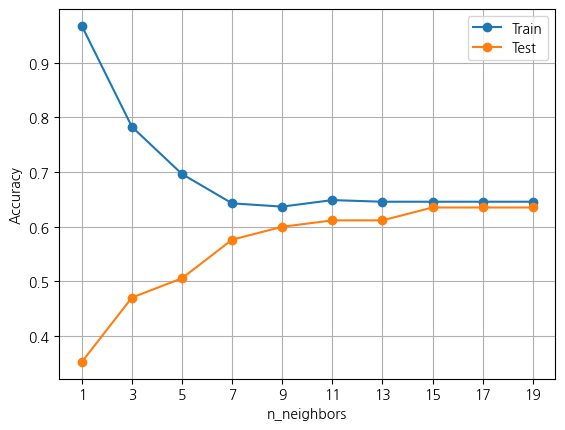

In [10]:

k_list = range(1, 21, 2)

plt.plot(k_list, train_scores, marker='o', label='Train')
plt.plot(k_list, test_scores, marker='o', label='Test')

plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.xticks(k_list)
plt.legend()
plt.grid()
plt.show()

- **그나마 최적은 k=15**

In [11]:
best_index = test_scores.index(max(test_scores))
best_k = list(k_list)[best_index]

print('최적 k:', best_k)
print('최고 Test Score:', max(test_scores))

최적 k: 15
최고 Test Score: 0.6352941176470588


In [12]:
kModel = KNeighborsClassifier(n_neighbors=best_k)
kModel.fit(X_train, y_train)

print(f'Train Score : {kModel.score(X_train, y_train):.4f}')
print(f'Test Score  : {kModel.score(X_test, y_test):.4f}')

Train Score : 0.6458
Test Score  : 0.6353


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

kModel = KNeighborsClassifier()

param_dict = {
    'n_neighbors': range(1, 51, 2),
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

skFold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=10
)

rsModel = RandomizedSearchCV(
    estimator=kModel,
    param_distributions=param_dict,
    cv=skFold,
    n_iter=50,
    scoring='accuracy',
    random_state=10,
    return_train_score=True,
    n_jobs=-1
)

rsModel.fit(X_train, y_train)

print('최적 파라미터:', rsModel.best_params_)
print('최고 검증 점수:', rsModel.best_score_)
print('학습 점수:', rsModel.best_estimator_.score(X_train, y_train))
print('테스트 점수:', rsModel.best_estimator_.score(X_test, y_test))

c:\Users\KDT30\anaconda3\envs\hanicv\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.63393327 0.58617208        nan        nan 0.53279192 0.63691835
        nan 0.58024583 0.63691835        nan 0.63990342        nan
 0.6428885  0.63990342 0.63990342 0.63691835 0.63393327 0.63691835
 0.6428885  0.63990342        nan 0.63990342 0.63994732 0.63990342
 0.54179104 0.63990342 0.63990342 0.4404302  0.63990342        nan
 0.63393327 0.63990342 0.63691835 0.63990342 0.63990342        nan
 0.63990342 0.63691835        nan        nan        nan 0.62497805
        nan 0.63990342 0.62506585 0.63990342 0.5238367  0.63990342
 0.61619842 0.63691835]
  warnings.warn(
c:\Users\KDT30\anaconda3\envs\hanicv\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the train scores are non-finite: [0.64880708 0.68900017        nan        nan 0.76043112 0.64583033
        nan 0.6875104  0.64583033        na

최적 파라미터: {'p': 2, 'n_neighbors': 11, 'algorithm': 'kd_tree'}
최고 검증 점수: 0.6428884986830553
학습 점수: 0.6488095238095238
테스트 점수: 0.6


근데 여기서는 k=11이 최적

In [15]:
# RandomizedSearchCV의 베스트 모델 저장
best_rs_model = rsModel.best_estimator_

print(best_rs_model)

print(f'Random Search Train Score : {best_rs_model.score(X_train, y_train):.4f}')
print(f'Random Search Test Score  : {best_rs_model.score(X_test, y_test):.4f}')

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=11)
Random Search Train Score : 0.6488
Random Search Test Score  : 0.6000


GridSearchCV

In [16]:

kModel = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 51, 2),
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

gsModel = GridSearchCV(
    estimator=kModel,
    param_grid=param_grid,
    cv=skFold,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

gsModel.fit(X_train, y_train)

print('최적 파라미터:', gsModel.best_params_)
print('최고 검증 점수:', gsModel.best_score_)
print('학습 점수:', gsModel.best_estimator_.score(X_train, y_train))
print('테스트 점수:', gsModel.best_estimator_.score(X_test, y_test))

c:\Users\KDT30\anaconda3\envs\hanicv\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.4404302         nan 0.52093942        nan 0.58617208
        nan 0.62497805        nan 0.63393327        nan 0.63994732
        nan 0.63691835        nan 0.63393327        nan 0.6428885
        nan 0.63691835        nan 0.63990342        nan 0.63990342
        nan 0.6428885         nan 0.63990342        nan 0.63990342
        nan 0.6428885         nan 0.63990342        nan 0.63990342
        nan 0.63990342        nan 0.63990342        nan 0.63990342
        nan 0.63990342        nan 0.63990342        nan 0.63990342
        nan 0.63990342 0.46712028 0.4404302  0.53279192 0.52093942
 0.5953029  0.58024583 0.61619842 0.62199298 0.62506585 0.63393327
 0.63402107 0.63994732 0.63393327 0.63691835 0.63691835 0.63393327
 0.63691835 0.6428885  0.63990342 0.63691835 0.63990342 0.63990342
 0.63990342 0.63990342 0.6428885  0.64288

최적 파라미터: {'algorithm': 'kd_tree', 'n_neighbors': 11, 'p': 2}
최고 검증 점수: 0.6428884986830553
학습 점수: 0.6488095238095238
테스트 점수: 0.6


In [17]:
# GridSearchCV의 베스트 모델 저장
best_gs_model = gsModel.best_estimator_

print(best_gs_model)

print(f'Grid Search Train Score : {best_gs_model.score(X_train, y_train):.4f}')
print(f'Grid Search Test Score  : {best_gs_model.score(X_test, y_test):.4f}')

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=11)
Grid Search Train Score : 0.6488
Grid Search Test Score  : 0.6000


In [18]:
print('[RandomizedSearchCV 결과]')
print('Best Params:', rsModel.best_params_)
print(f'Best CV Score : {rsModel.best_score_:.4f}')
print(f'Train Score   : {best_rs_model.score(X_train, y_train):.4f}')
print(f'Test Score    : {best_rs_model.score(X_test, y_test):.4f}')

print()

print('[GridSearchCV 결과]')
print('Best Params:', gsModel.best_params_)
print(f'Best CV Score : {gsModel.best_score_:.4f}')
print(f'Train Score   : {best_gs_model.score(X_train, y_train):.4f}')
print(f'Test Score    : {best_gs_model.score(X_test, y_test):.4f}')

[RandomizedSearchCV 결과]
Best Params: {'p': 2, 'n_neighbors': 11, 'algorithm': 'kd_tree'}
Best CV Score : 0.6429
Train Score   : 0.6488
Test Score    : 0.6000

[GridSearchCV 결과]
Best Params: {'algorithm': 'kd_tree', 'n_neighbors': 11, 'p': 2}
Best CV Score : 0.6429
Train Score   : 0.6488
Test Score    : 0.6000


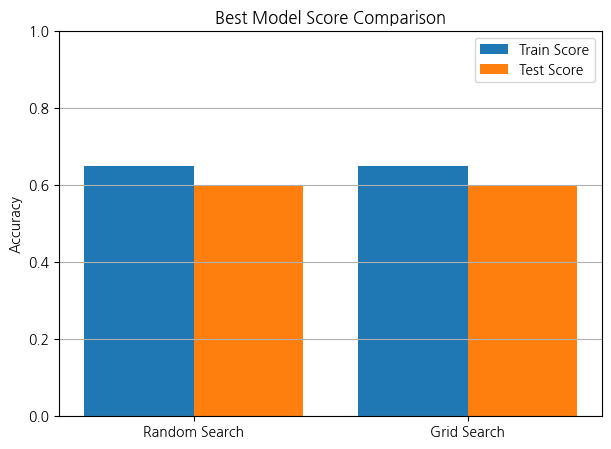